In [13]:
import sys
sys.path.append("/home/plgrid/plgmichalbrz/take_1")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from algorithms import globals
import os
import numpy as np

num_of_thresholds = 1000



In [15]:
def scale(x):
    a, b = globals.def_clamps
    c, d = globals.original_clamps

    x_scaled = ((x - a) / (b - a)) * (d - c) + c
    return x_scaled



In [16]:
logs = [
    { "name" : "adagrad", "path": "./Adagrad/ada_net_logs/ada_net_records.csv", "run_path": "./Adagrad/ada_net_logs/ada_net_run_records.csv"},
    { "name" : "L_BFGS_B", "path": "./BFGS/bfgs_net_logs/bfgs_net_records.csv", "run_path": "./BFGS/bfgs_net_logs/bfgs_net_run_records.csv"},
    { "name" : "adam", "path": "./Adam/adam_net_logs/adam_net_records.csv", "run_path": "./Adam/adam_net_logs/adam_net_run_records.csv"},
    { "name" : "cmaes", "path": "./CMAES/cmaes_net_logs/cmaes_net_records.csv", "run_path": "./CMAES/cmaes_net_logs/cmaes_net_run_records.csv"},
    { "name" : "nl_shade", "path": "./NLShade/nl_net_logs/nl_net_records.csv", "run_path": "./NLShade/nl_net_logs/nl_net_run_records.csv"},

]

In [17]:
def get_records(path):

    if not os.path.exists(path):
        records = None
    else:
        records = []
        with open(path, mode='r', newline='') as file:
            reader = csv.DictReader(file)
            for row in reader:
                converted_row = {
                    key: (float(value.strip('[]')) if key != 'algorithm' else value)
                    for key, value in row.items()
                }
                records.append(converted_row)

    return records


In [18]:

def calculate_thresholds(algs_run_records):

    all_errors = [
        r['error']
        for records in algs_run_records.values()
        for r in records
    ]

    all_errors = np.array(all_errors)
    all_errors = all_errors[all_errors >= globals.def_smallest_val]

    percentiles = np.linspace(0, 100, num=num_of_thresholds + 1)
    thresholds = np.percentile(all_errors, percentiles)


    # min_error = np.min(all_errors)
    # max_error = np.max(all_errors)

    # min_error = max(min_error, globals.def_smallest_val)

    # # thresholds = np.linspace(min_error, max_error, num=num_of_thresholds + 1)
    # # thresholds = np.percentile(all_errors, percentiles)
    # thresholds = np.logspace(
    #     np.log10(min_error),
    #     np.log10(max_error),
    #     num=num_of_thresholds
    # )
    return thresholds

In [19]:
def ecdf(run_records, thresholds):
    checkpoint_run_errors = {}

    for r in run_records:
        chk = r['checkpoint']
# TODO        # error = (1-r['error'])
        error = r['error']
        if chk not in checkpoint_run_errors:
            checkpoint_run_errors[chk] = []
        checkpoint_run_errors[chk].append(error)

    avg_part_of_thresholds_reached = []
    prev_reached = None

    for chk in globals.def_checkpoints:
        errors = checkpoint_run_errors.get(chk, [])
        if not errors:
            if prev_reached is None:
                avg_part_of_thresholds_reached.append(0)
            else:
                avg_part_of_thresholds_reached.append(np.mean(prev_reached))
            continue

        fractions = []
        for e in errors:
            reached_now = e <= thresholds

            if prev_reached is not None:
                reached_now = np.maximum(prev_reached, reached_now)

            fractions.append(np.sum(reached_now) / len(thresholds))

        avg_fraction = np.mean(fractions)
        avg_part_of_thresholds_reached.append(avg_fraction)

        combined_reached = np.zeros(len(thresholds), dtype=bool)
        for e in errors:
            combined_reached = np.maximum(combined_reached, e <= thresholds)

        if prev_reached is None:
            prev_reached = combined_reached
        else:
            prev_reached = np.maximum(prev_reached, combined_reached)

    return avg_part_of_thresholds_reached



In [20]:
def compare(logs):
    checkpoints = globals.def_checkpoints

    algs_run_records = {}
    algs_records = {}

    for algorithm in logs:
        algs_records[algorithm['name']] = get_records(f"{algorithm['path']}")
        algs_run_records[algorithm['name']] = get_records(f"{algorithm['run_path']}")

    fig, axs = plt.subplots(1, 2, figsize=(20, 8))
    axs = axs.flatten()
    plot_idx = 0

    # ECDF
    ecdf_thresholds = calculate_thresholds(algs_run_records)

    ax = axs[plot_idx]
    for algorithm_name, run_record in algs_run_records.items():
        y = ecdf(run_record, ecdf_thresholds)
        ax.plot(globals.def_checkpoints, y, label=algorithm_name, marker='o')

    ax.set_xlabel('Checkpoint (evaluations)')
    ax.set_ylabel('Fraction of thresholds reached (ECDF)')
    ax.set_title(f"learning method comparison, ECDF")
    ax.set_xscale('log')
    ax.set_ylim([0, 1.05])
    ax.grid(True)
    ax.legend()

    plot_idx += 1

    # Mean + Std
    ax = axs[plot_idx]
    for algorithm_name, records in algs_records.items():
        means = []
        stds = []

        for checkpoint in checkpoints:
            if records:
                mean_vals = [r['mean'] for r in records if r['checkpoint'] == checkpoint]
                std_vals = [r['std'] for r in records if r['checkpoint'] == checkpoint]
                means.append(np.mean(mean_vals) if mean_vals else 0)
                stds.append(np.mean(std_vals) if std_vals else 0)
            else:
                means.append(0)
                stds.append(0)

        ax.plot(checkpoints, means, label=algorithm_name, marker='o')
        ax.fill_between(checkpoints,
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        alpha=0.2)

    ax.set_xlabel('Checkpoint')
    ax.set_ylabel("Loss")
    ax.set_title(f"learning method comparison, mean and std")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)

    plot_idx += 1

    plt.tight_layout()
    # plt.savefig(f"./charts/net/1.png", transparent=False, facecolor='white', dpi=300)

    plt.show()


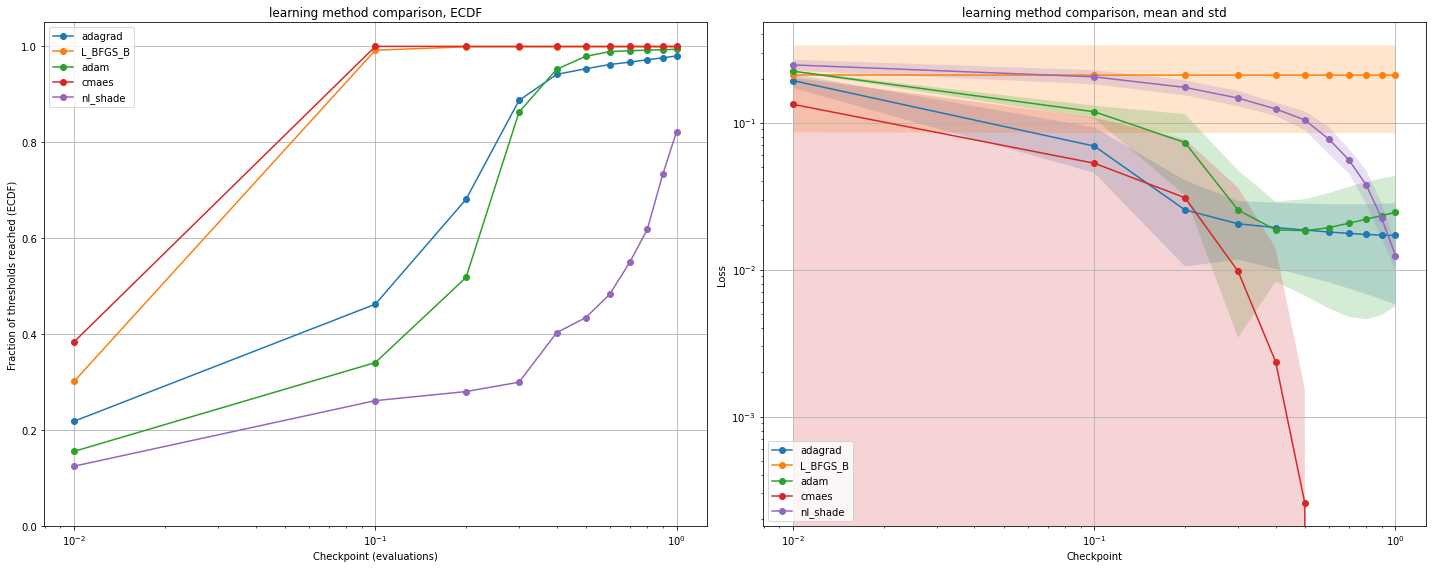

In [21]:
to_compare = []

# indxs = [3, 4, 5, 6, ]
# indxs = [10, 11, 12]
indxs = [0, 1, 2, 3, 4]

for i in indxs:
    to_compare.append(logs[i])

compare(to_compare)